In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime, date, timedelta
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors

ENEL, TENARIS, POSTE, DIASORIN. CASH COLLECT MEMORY CALLABLE (NON COMPLETATO)

In [6]:
# PREZZO CERTIFICATE
prezzo = 936.6

In [7]:
# DATI PANIERE
yf.set_tz_cache_location("C:/yf_cache")

tickers = ["ENEL.MI", "TEN.MI", "PST.MI", "DIA.MI"]   
dati = yf.download(tickers, period='max', auto_adjust=False)["Close"]
dati.dropna(inplace=True)
dati = dati.reindex(pd.date_range(str(dati.index[0]), str(dati.index[-1])), method="ffill")

[*********************100%***********************]  4 of 4 completed


In [8]:
dati.head(30)

Ticker,DIA.MI,ENEL.MI,PST.MI,TEN.MI
2015-10-27,40.259998,4.154,6.700,11.17
2015-10-28,40.389999,4.234,6.700,11.53
2015-10-29,41.400002,4.142,6.410,11.53
2015-10-30,40.740002,4.196,6.500,11.42
2015-10-31,40.740002,4.196,6.500,11.42
2015-11-01,40.740002,4.196,6.500,11.42
2015-11-02,41.509998,4.240,6.600,11.41
2015-11-03,41.740002,4.214,6.580,11.87
2015-11-04,41.810001,4.204,6.545,11.70
2015-11-05,41.259998,4.140,6.550,11.69


<Axes: >

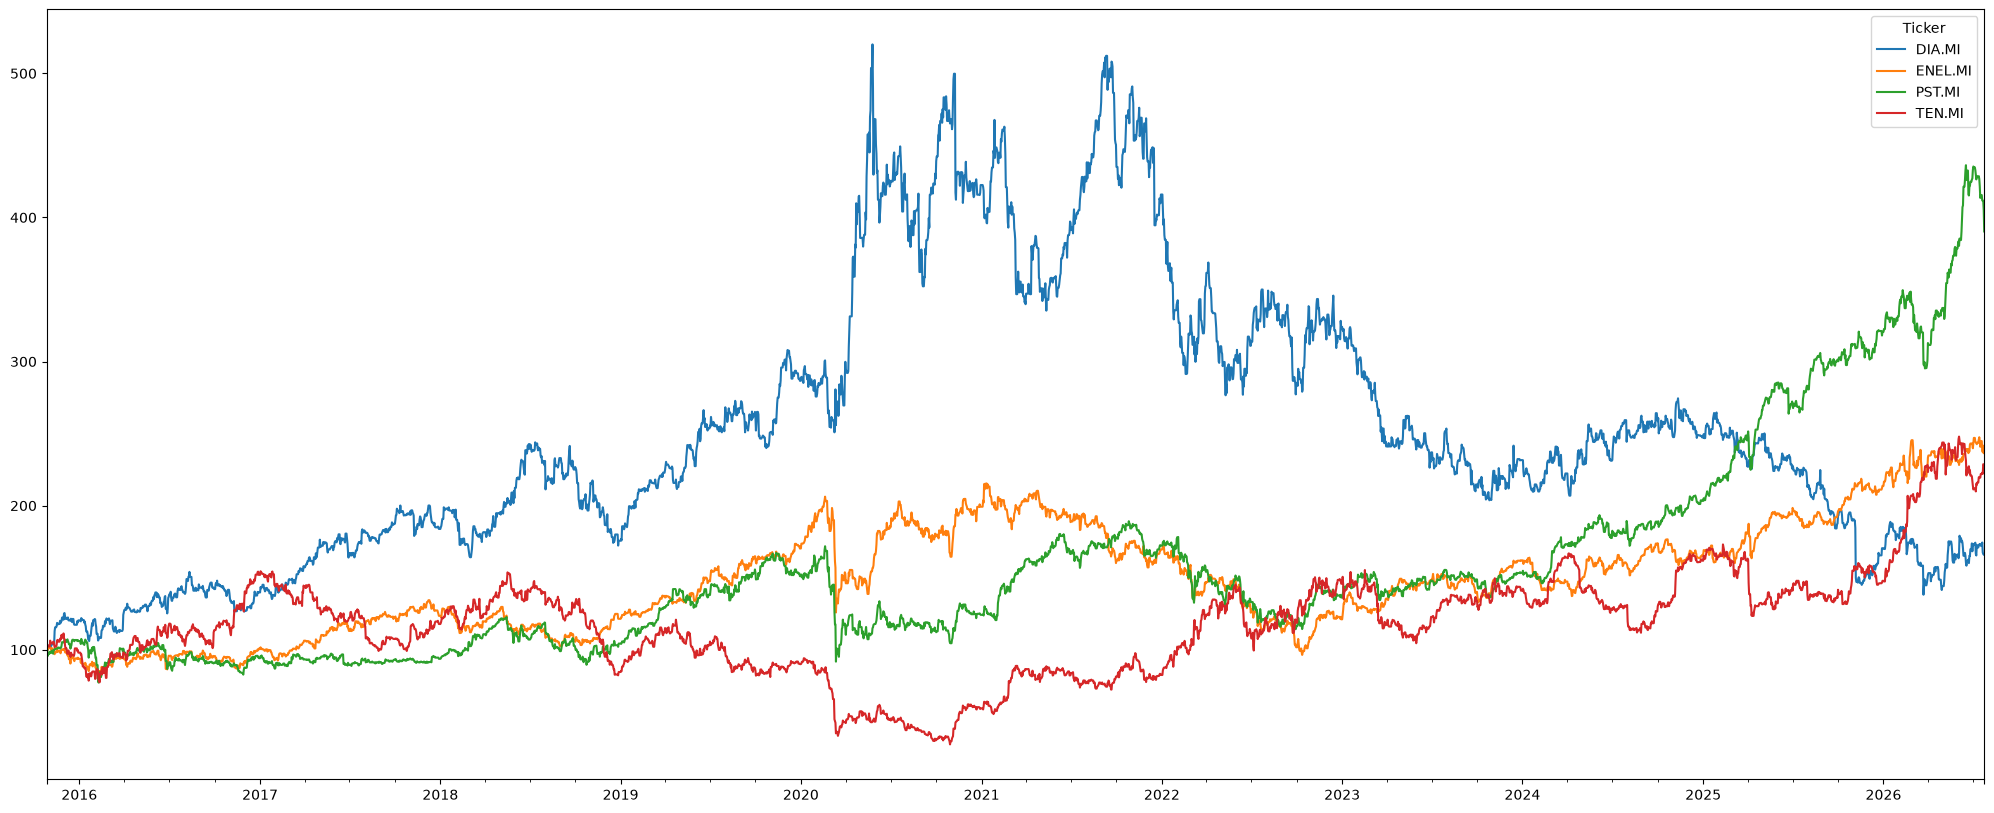

In [9]:
(100*dati/dati.iloc[0]).plot(figsize=(25,10))

In [ ]:
# PARAMETRI DEL PRODOTTO
rimborso = 1000
fixing   = {6.103, 17.99, 11.47, 91.82}  
barriere = {3.0515, 8.995, 5.735, 45.91}         

date_rimborso_anticipato = [
                datetime.strptime("20.08.2026", '%d.%m.%Y').date(),
                datetime.strptime("21.09.2026", '%d.%m.%Y').date(),
                datetime.strptime("20.10.2026", '%d.%m.%Y').date(),
                datetime.strptime("20.11.2026", '%d.%m.%Y').date(),
                datetime.strptime("21.12.2026", '%d.%m.%Y').date(),
                datetime.strptime("20.01.2027", '%d.%m.%Y').date(),
                datetime.strptime("22.02.2027", '%d.%m.%Y').date()
                ]
fine     = datetime.strptime("22.03.2027", "%d.%m.%Y").date() 

In [19]:
#PREMIO MENSILE
premio_importo = rimborso * 0.0095

def premi_incassati(data_rimborso):
    n = sum(1 for d in date_rimborso_anticipato if d <= data_rimborso)
    return n * premio_importo

In [20]:
giorni_durata = abs((datetime.today().date()-fine).days)   

# cattura il prezzo VERO di oggi, prima del dropna della cella 8
spot = {t: dati[t].iloc[-1] for t in tickers}

dati["finale_media"] = 0
for t in tickers:
    for i in range(len(date_rimborso_anticipato)):
        gg = (date_rimborso_anticipato[i]-datetime.today().date()).days   
        if gg > 0:
            dati["autocall_"+t+"_"+str(i)] = dati[t].shift(-gg)/dati[t] - 1
    dati["finale_"+t] = dati[t].shift(-giorni_durata)/dati[t] - 1
    dati["finale_media"] += dati["finale_"+t]/len(tickers)

dati.dropna(inplace=True)

In [21]:
dati

Ticker,F,GT,HOG,finale_media,autocall_F_0,autocall_F_1,autocall_F_2,finale_F,autocall_GT_0,autocall_GT_1,autocall_GT_2,finale_GT,autocall_HOG_0,autocall_HOG_1,autocall_HOG_2,finale_HOG
1986-07-08,4.721573,15.9375,0.343750,0.124274,0.065217,0.154589,-0.016908,0.108696,-0.039216,0.090196,0.019608,0.525490,0.079546,-0.113635,-0.272727,-0.261364
1986-07-09,4.744383,16.0000,0.398438,0.086717,0.052885,0.149038,0.004808,0.103365,-0.035156,0.085938,0.031250,0.519531,-0.078431,-0.235294,-0.382353,-0.362747
1986-07-10,4.778597,16.2500,0.406250,0.072206,0.021480,0.140811,0.011933,0.095465,-0.065385,0.069231,0.073077,0.496154,-0.115385,-0.249999,-0.413462,-0.375001
1986-07-11,4.767192,16.1250,0.433594,0.077900,0.019139,0.143541,0.033493,0.133971,-0.054264,0.077519,0.069767,0.496124,-0.162163,-0.297297,-0.423424,-0.396396
1986-07-12,4.767192,16.1250,0.433594,0.067603,0.019139,0.119617,0.047847,0.117225,-0.054264,0.085271,0.042636,0.500000,-0.162163,-0.333333,-0.405405,-0.414415
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,11.370000,6.4400,19.469999,0.261173,0.131926,0.145998,0.227792,0.230431,0.096273,-0.128882,-0.043478,0.124224,0.206472,0.250642,0.305085,0.428865
2026-03-28,11.370000,6.4400,19.469999,0.282756,0.131926,0.148637,0.236588,0.255057,0.096273,-0.130435,-0.038820,0.131988,0.206472,0.199795,0.318439,0.461222
2026-03-29,11.370000,6.4400,19.469999,0.281225,0.131926,0.162709,0.236588,0.268250,0.096273,-0.133540,-0.038820,0.156832,0.206472,0.224962,0.318439,0.418593
2026-03-30,11.210000,6.2900,19.440001,0.248037,0.148082,0.219447,0.254237,0.262266,0.147854,-0.066773,-0.015898,0.117647,0.231996,0.193416,0.320473,0.364198


In [22]:
conto_non_normalizzato = True

rendimenti = []
for giorno in range(len(dati)):
    for i in range(len(date_rimborso_anticipato)):
        if (datetime.today().date()-date_rimborso_anticipato[i]).days<0: # escludiamo gli autocall già successi
            autocall = True
            for t in tickers:
                if  spot[t] * (1+dati["autocall_"+t+"_"+str(i)].iloc[giorno]) < fixing[t] * (autocall_perc[i]) :
                    autocall = False
                    break # non c'è autocall e esco dal loop dei tickers

            if autocall:
                if conto_non_normalizzato:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( incasso )
                else:
                    incasso = rimborso + premi_incassati(date_rimborso_anticipato[i])
                    rendimenti.append( (incasso/prezzo)**(365.24/(date_rimborso_anticipato[i]-datetime.today().date()).days) - 1 )
                break # esco anche dal loop degli autocall

    if not autocall: # se arrivo qui con autocall False vuol dire che sono passato attraverso tutti i tentativi di autocall
        chi_rapporto_peggiore = ""
        evento_barriera = False
        rapporto_peggiore_su_fixing = 999
        for t in tickers: # cerco il rapporto peggiore RISPETTO AL PREZZO DI FIXING!
            if spot[t] * (1+dati["finale_"+t].iloc[giorno]) <= barriere[t]: # scatta evento barriera
                rapporto = (spot[t] * (1+dati["finale_"+t].iloc[giorno]) ) /fixing[t] # questo rapporto è per forza <= 0.5
                if evento_barriera:
                    if rapporto < rapporto_peggiore_su_fixing:
                        chi_rapporto_peggiore = t
                        rapporto_peggiore_su_fixing = rapporto
                else:
                    evento_barriera = True
                    chi_rapporto_peggiore = t
                    rapporto_peggiore_su_fixing = rapporto

        if evento_barriera:
            rimborso_alternativo = max(0,rimborso*rapporto_peggiore_su_fixing)
            if conto_non_normalizzato:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso_alternativo + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )

        else:
            if conto_non_normalizzato:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( incasso )
            else:
                incasso = rimborso + premi_incassati(fine)
                rendimenti.append( (incasso/prezzo)**(365.24/(fine-datetime.today().date()).days) - 1 )


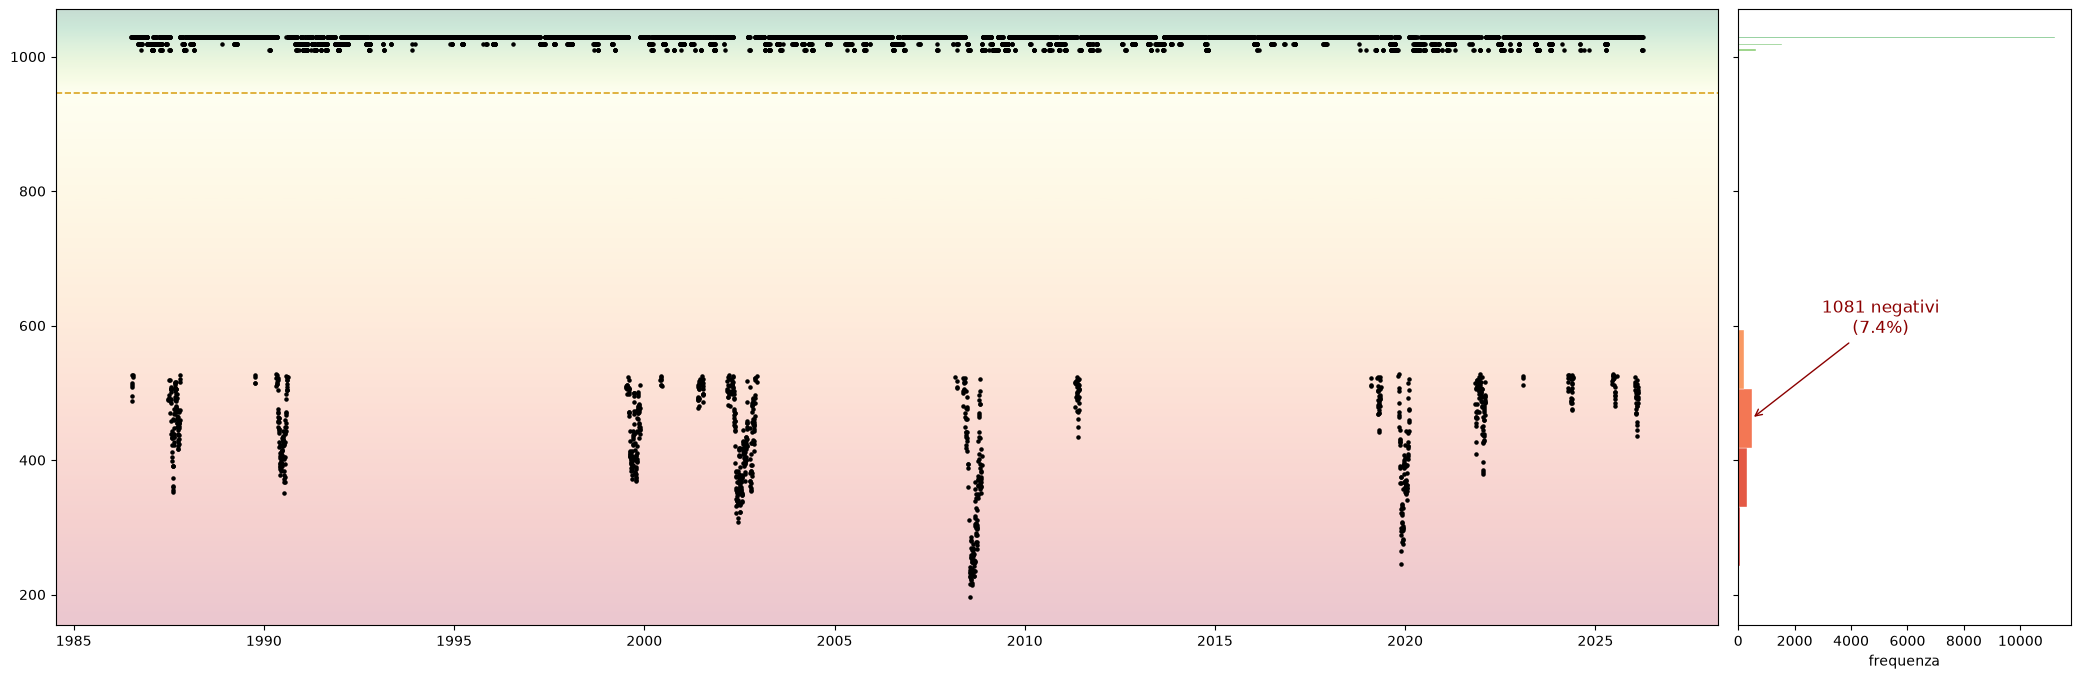

In [23]:
s = pd.Series(rendimenti, index=dati.index)
center = prezzo if conto_non_normalizzato else 0.0

ymin, ymax = s.min(), s.max()
pad = (ymax - ymin) * 0.05
ymin -= pad; ymax += pad
norm = mcolors.TwoSlopeNorm(vmin=ymin, vcenter=center, vmax=ymax)
cmap = plt.get_cmap("RdYlGn")

fig, (ax, axh) = plt.subplots(1, 2, figsize=(26, 8), sharey=True,
                              gridspec_kw={"width_ratios": [5, 1], "wspace": 0.02})

# --- scatter + sfondo semaforo ---
ax.scatter(s.index, s.values, s=5, c="black", zorder=2)
x0, x1 = ax.get_xlim()
ax.imshow(np.linspace(ymax, ymin, 256).reshape(-1, 1), extent=[x0, x1, ymin, ymax],
          aspect="auto", cmap=cmap, norm=norm, alpha=0.22, zorder=0)
ax.axhline(center, color="goldenrod", lw=1.2, ls="--", zorder=1)
ax.set_xlim(x0, x1); ax.set_ylim(ymin, ymax)

# --- istogramma: bin larghi sotto il centro, fitti sopra ---
edges = np.concatenate([np.linspace(ymin, center, 10),      # ~9 bin larghi (perdite)
                        np.linspace(center, ymax, 60)[1:]]) # bin fitti (parte positiva)
counts, edges = np.histogram(s.values, bins=edges)
centers = (edges[:-1] + edges[1:]) / 2
widths = np.diff(edges)
axh.barh(centers, counts, height=widths, color=cmap(norm(centers)),
         alpha=0.9, edgecolor="white", linewidth=0.3)
axh.set_xlabel("frequenza")
axh.tick_params(labelleft=False)

# --- freccina col conteggio dei negativi ---
neg = centers < center
n_neg = int(counts[neg].sum())
pct = n_neg / len(s) * 100
y_neg = centers[neg][np.argmax(counts[neg])]
x_neg = counts[neg].max()
axh.annotate(f"{n_neg} negativi\n({pct:.1f}%)",
             xy=(x_neg, y_neg),                                   
             xytext=(counts.max() * 0.45, center - (center - ymin) * 0.45),  
             ha="center", fontsize=12, color="darkred",
             arrowprops=dict(arrowstyle="->", color="darkred"))

plt.show()

In [24]:
pd.Series(rendimenti,index=dati.index).describe()

count    14512.000000
mean       982.441092
std        156.601197
min        195.619375
25%       1028.500000
50%       1028.500000
75%       1028.500000
max       1028.500000
dtype: float64

## Valutazione tramite Certainty Equivalent (utilità CRRA)

**Equivalente certo** — importo certo che rende indifferente al possesso dello strumento rischioso:

$$\text{CE} = u^{-1}\big(\mathbb{E}[u(X)]\big), \qquad u(x) = \frac{x^{1-\gamma}}{1-\gamma}$$

Sulla distribuzione empirica dei payoff $\{x_i\}_{i=1}^{N}$:

$$\text{CE}(\gamma) = \left(\frac{1}{N}\sum_{i=1}^{N} x_i^{\,1-\gamma}\right)^{\frac{1}{1-\gamma}} \quad (\gamma \neq 1), \qquad \text{CE}(1) = \exp\!\left(\frac{1}{N}\sum_{i=1}^{N} \ln x_i\right)$$

**Valore oggi** (scontato al tasso risk-free $r$ su orizzonte $T$):

$$V(\gamma) = e^{-rT}\,\text{CE}(\gamma)$$

**Casi particolari e interpretazione:**

- $\gamma = 0$ (neutrale al rischio): $\text{CE} = \frac{1}{N}\sum_i x_i = \mathbb{E}[X]$, cioè la sola media → $V = e^{-rT}\,\mathbb{E}[X]$.
- $\gamma > 0$: la concavità di $u$ penalizza la coda sinistra; più alto è $\gamma$, più $\text{CE}$ scende sotto la media.
- **Premio per il rischio:** $\ \pi(\gamma) = \mathbb{E}[X] - \text{CE}(\gamma)$
- **Regola di decisione:** $\ V(\gamma) > \text{prezzo} \Rightarrow$ conviene; $\ V(\gamma) < \text{prezzo} \Rightarrow$ paghi troppo per quel rischio.

## Come interpretare γ: il test della scommessa 50/50

Per dare un significato concreto a γ, traducilo in una scommessa: **50/50 — o raddoppi il capitale, o ne perdi una frazione L**. La massima perdita L che accetteresti individua la tua avversione al rischio.

Condizione di indifferenza (utilità CRRA):

$$0.5 \cdot 2^{\,1-\gamma} + 0.5 \cdot (1-L)^{\,1-\gamma} = 1$$

| γ | Max perdita L accettata per un 50/50 di raddoppiare | Profilo |
|---|---|---|
| 0,5 | 66% | molto aggressivo |
| 1 | 50% | aggressivo (log / Kelly) |
| 2 | 33% | moderato |
| 3 | 24% | moderato-prudente |
| 5 | 15% | prudente |
| 10 | 7% | molto prudente |
| 20 | 4% | avversissimo |

**Lettura:** se pur di avere il 50% di probabilità di raddoppiare accetti di rischiare di perdere metà del capitale → γ ≈ 1; se il massimo che tolleri è −15% → γ ≈ 5.

**Riferimenti empirici:** investitore individuale tipico γ ≈ 2–4; profili prudenti γ ≈ 5–10; fascia realistica complessiva 1–10 (default ragionevole 2–4).

In [ ]:
X = np.array(rendimenti, dtype=float)      # richiede conto_non_normalizzato = True
r = 0.03
T = giorni_durata / 365.24
disc = np.exp(-r*T)

def V(g):                                  # valore scontato al variare di gamma
    ce = np.exp(np.mean(np.log(X))) if abs(g-1) < 1e-9 else np.mean(X**(1-g))**(1/(1-g))
    return disc * ce

gammas = np.linspace(0, 10, 400)
vals = np.array([V(g) for g in gammas])

# gamma di break-even: dove la curva incrocia il prezzo
gamma_be = None
sign = np.sign(vals - prezzo)
idx = np.where(np.diff(sign) != 0)[0]
if len(idx):
    i = idx[0]; g0, g1 = gammas[i], gammas[i+1]; v0, v1 = vals[i], vals[i+1]
    gamma_be = g0 + (prezzo - v0) * (g1 - g0) / (v1 - v0)

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(gammas, vals, lw=2, color="tab:blue", label=r"valore scontato $V(\gamma)=e^{-rT}CE(\gamma)$")
ax.axhline(prezzo, color="crimson", ls="--", lw=1.5, label=f"prezzo di mercato = {prezzo:.1f}")

# zone conviene (verde) / non conviene (rosso)
ax.fill_between(gammas, vals, prezzo, where=(vals >= prezzo), color="tab:green", alpha=0.12)
ax.fill_between(gammas, vals, prezzo, where=(vals <  prezzo), color="tab:red",   alpha=0.12)

if gamma_be is not None:
    ax.axvline(gamma_be, color="goldenrod", ls=":", lw=1.5)
    ax.plot(gamma_be, prezzo, "o", color="black", zorder=5)
    ax.annotate(f"break-even  γ = {gamma_be:.2f}",
                xy=(gamma_be, prezzo),
                xytext=(gamma_be + 0.4, prezzo + (vals.max()-vals.min())*0.12),
                arrowprops=dict(arrowstyle="->"))

ax.set_xlabel("γ  (avversione al rischio)")
ax.set_ylabel("valore oggi")
ax.set_title("Valore dello strumento in funzione dell'avversione al rischio")
ax.legend()
plt.tight_layout()
plt.show()